# 🏆 进阶挑战 (Advanced AB Testing Challenge)

欢迎来到 A/B 测试进阶关卡！这里没有保姆级的 Step-by-Step 指引。

你需要像一个真实的数据分析师一样：
1.  **理解业务** (Biz Context)
2.  **拿到数据** (Get Data)
3.  **决定方法** (Methodology)
4.  **得出结论** (Conclusion)

Good Luck! 🍀

# 🛠️ 武器库 (Cheat Sheet)

这里是你可能用到的神兵利器，请按需取用：

| 函数 | 作用 | 场景 (Scenario) |
| :--- | :--- | :--- |
| `ttest_ind(a, b)` | T检验 (均值) | 比较两个组的 **人均收入 (ARPU)**, **停留时长** |
| `chi2_contingency(table)` | 卡方检验 (频数) | 比较两个组的 **转化率**, **跳出率** (Yes/No) |
| `mannwhitneyu(a, b)` | 曼惠特尼 U 检验 | **数据极度偏态** (比如收入，大部分人是0，少数人巨高) |
| `pivot_table` / `groupby` | 透视表 | **拆解维度** (比如分渠道看、分人群看) |

In [1]:
# 🏗️ 数据生成 (Data Generation)
# 请先运行此 Cell 生成模拟数据！
import pandas as pd
import numpy as np
np.random.seed(42)

# --- Data 1: PDP Bounce Rate (Case 6) ---
n_pdp = 2000
df_pdp = pd.DataFrame({
    'visit_id': range(n_pdp),
    'group': np.random.choice(['Control', 'Test'], n_pdp),
})
# Control: 50% Bounce, Test: 45% Bounce (Better)
df_pdp['is_bounce'] = df_pdp['group'].map(lambda x: np.random.binomial(1, 0.50 if x == 'Control' else 0.45))

# --- Data 2: Coupon Revenue (Case 7) ---
n_coupon = 2000
df_coupon = pd.DataFrame({
    'user_id': range(n_coupon),
    'group': np.random.choice(['5元券', '10元券'], n_coupon),
})
# 5元券: 转化率 10%, 均单 50; 10元券: 转化率 15%, 均单 55 (Better ARPU)
def get_revenue(grp):
    if grp == '5元券':
        return np.random.binomial(1, 0.10) * np.random.normal(50, 10)
    else:
        return np.random.binomial(1, 0.15) * np.random.normal(55, 10)

df_coupon['revenue'] = df_coupon['group'].apply(get_revenue)
df_coupon['revenue'] = df_coupon['revenue'].clip(lower=0) # 修正负数

# --- Data 3: Simpson's Paradox (Case 8) ---
# 构造一个 Test 总转化率低，但分渠道都高的诡异数据
n_simpson = 3000
df_simpson = pd.DataFrame({
    'user_id': range(n_simpson),
})
# 渠道分布不均：Test 组全是烂渠道(Android)，Control 组全是好渠道(iOS)
# iOS (High Quality): Conv ~ 20%; Android (Low Quality): Conv ~ 5%
# Control: 90% iOS, 10% Android
# Test: 10% iOS, 90% Android
df_simpson['group'] = np.random.choice(['Control', 'Test'], n_simpson)

def get_channel(grp):
    if grp == 'Control': return np.random.choice(['iOS', 'Android'], p=[0.9, 0.1])
    else: return np.random.choice(['iOS', 'Android'], p=[0.1, 0.9])

df_simpson['channel'] = df_simpson['group'].apply(get_channel)

def get_conv(row):
    # Test 在各渠道都稍好一点点 (iOS: 21% vs 20%, And: 6% vs 5%)
    if row['channel'] == 'iOS':
        p = 0.21 if row['group'] == 'Test' else 0.20
    else:
        p = 0.06 if row['group'] == 'Test' else 0.05
    return np.random.binomial(1, p)

df_simpson['is_converted'] = df_simpson.apply(get_conv, axis=1)

print("✅ 数据已生成: df_pdp, df_coupon, df_simpson")

✅ 数据已生成: df_pdp, df_coupon, df_simpson


## 🔍 Case 6: 详情页改版 (Bounce Rate)

**场景**: 我们重新设计了商品详情页 (PDP)，希望 **降低** 用户跳出率 (Bounce Rate)。
**数据**: `df_pdp` (`visit_id`, `group`, `is_bounce`)
**Goal**: 验证 Test 组的跳出率是否显著低于 Control 组？

In [2]:
# ✍️ 你的代码 (Your Code)

print(df_pdp.info())
print(df_pdp.head())
df_pdp['visit_id'] = df_pdp['visit_id'].astype(str)
print(df_pdp.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   visit_id   2000 non-null   int64 
 1   group      2000 non-null   object
 2   is_bounce  2000 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 47.0+ KB
None
   visit_id    group  is_bounce
0         0  Control          0
1         1     Test          0
2         2  Control          1
3         3  Control          1
4         4  Control          1
       visit_id    group    is_bounce
count      2000     2000  2000.000000
unique     2000        2          NaN
top           0  Control          NaN
freq          1     1016          NaN
mean        NaN      NaN     0.482500
std         NaN      NaN     0.499819
min         NaN      NaN     0.000000
25%         NaN      NaN     0.000000
50%         NaN      NaN     0.000000
75%         NaN      NaN     1.000000
max         NaN      NaN     1.00

In [3]:
# 1. 算 mean (跳出率)
df_user_tb = df_pdp.groupby(['group','is_bounce'])['visit_id'].nunique().unstack()
df_user_tb = df_user_tb.reset_index()


In [4]:
df_user_tb
df_user_tb = df_user_tb.rename(columns={0: 'not_bounce', 1: 'bounce'})
df_user_tb['group_user_cnt'] = df_user_tb['not_bounce']+df_user_tb['bounce']
df_user_tb['bounce_rate'] = df_user_tb['bounce']/df_user_tb['group_user_cnt'] 
df_user_tb

is_bounce,group,not_bounce,bounce,group_user_cnt,bounce_rate
0,Control,509,507,1016,0.499016
1,Test,526,458,984,0.465447


In [5]:
# 2. 选检验方法 (T-test? Chi-Square?)
import scipy.stats as stats

control_group = df_pdp[df_pdp['group'] == 'Control']
test_group = df_pdp[df_pdp['group'] == 'Test']

result = stats.ttest_ind(control_group['is_bounce'],test_group['is_bounce'])

# 3. 看 P-value

print(f"P-value:{round(result[1],4)}")

alpha = 0.05
if result[1] < alpha:
    print(f"\n显著，拒绝原假设：Test组对跳出率降低有显著影响\n{df_user_tb.set_index('group')['bounce_rate']}")
else:
    print(f"\n不显著，接受原假设：Test组对跳出率降低无显著影响\n{df_user_tb.set_index('group')['bounce_rate']})")

test_bounce_rate = df_user_tb[df_user_tb['group'] == 'Test']['bounce_rate']
control_bounce_rate = df_user_tb[df_user_tb['group'] == 'Control']['bounce_rate'] 
result_bounce_rate = test_bounce_rate.values[0] - control_bounce_rate.values[0]
print(f"\ntest组跳出率优化效果：{round(result_bounce_rate,4)}")


P-value:0.1332

不显著，接受原假设：Test组对跳出率降低无显著影响
group
Control    0.499016
Test       0.465447
Name: bounce_rate, dtype: float64)

test组跳出率优化效果：-0.0336


In [6]:
# 🔑 参考答案 (Reference) - 点击展开
import scipy.stats as stats

# 1. 观察数据
print(df_pdp.groupby('group')['is_bounce'].mean())

# 2. 检验 (这是 0/1 分布，样本量大，可以用 T-test 近似，也可以用卡方)
# 这里演示最简单的 T-test
group_c = df_pdp[df_pdp['group'] == 'Control']['is_bounce']
group_t = df_pdp[df_pdp['group'] == 'Test']['is_bounce']

t_stat, p_val = stats.ttest_ind(group_c, group_t)
print(f"P-value: {p_val:.4f}")

# 结论: P < 0.05，拒绝原假设，Test 组跳出率显著降低 (0.45 vs 0.50)，改版成功！🎉

group
Control    0.499016
Test       0.465447
Name: is_bounce, dtype: float64
P-value: 0.1332


## 🔍 Case 7: 优惠券金额测试 (Revenue / ARPU)

**场景**: 发 5元 vs 10元 优惠券。
**数据**: `df_coupon` (`user_id`, `group`, `revenue`)
**Goal**: 10元券组的 ARPU (人均收入) 是否显著更高？
*(注意观察 revenue 的分布！)*

In [7]:
# ✍️ 你的代码 (Your Code)
print(df_coupon.info())
print(df_coupon.head())
df_coupon['user_id'] = df_coupon['user_id'].astype(str)
print(df_coupon.describe(include='all'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  2000 non-null   int64  
 1   group    2000 non-null   object 
 2   revenue  2000 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 47.0+ KB
None
   user_id group  revenue
0        0   5元券      0.0
1        1   5元券      0.0
2        2   5元券      0.0
3        3  10元券      0.0
4        4   5元券      0.0
       user_id group      revenue
count     2000  2000  2000.000000
unique    2000     2          NaN
top          0   5元券          NaN
freq         1  1003          NaN
mean       NaN   NaN     6.125206
std        NaN   NaN    17.146792
min        NaN   NaN     0.000000
25%        NaN   NaN     0.000000
50%        NaN   NaN     0.000000
75%        NaN   NaN     0.000000
max        NaN   NaN    73.907662


<Axes: xlabel='revenue', ylabel='Count'>

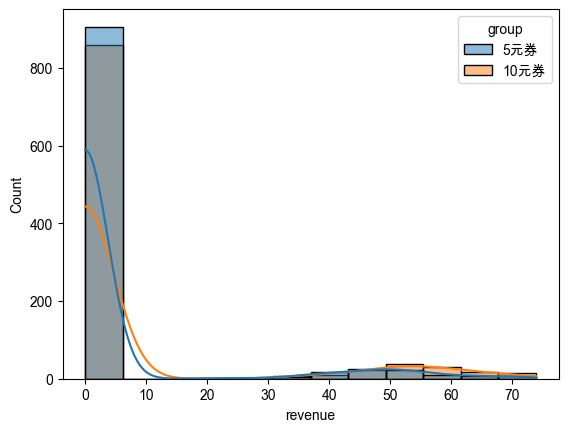

In [8]:
# 1. 看看 revenue 的分布 (hist)
import seaborn as sns
import matplotlib.pyplot as plt
# Mac 用户 (推荐):
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# Windows 用户:
# plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题
sns.histplot(data = df_coupon,x='revenue',kde=True,hue='group')

<Axes: xlabel='group', ylabel='revenue'>

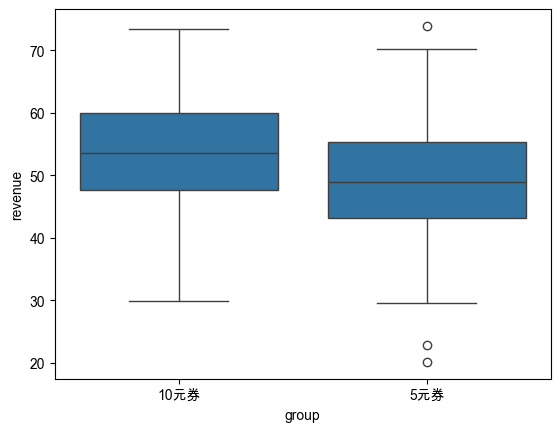

In [9]:
df_coupon_distribution = df_coupon[df_coupon['revenue'] > 0]
sns.boxplot(data = df_coupon_distribution, x='group', y='revenue')


In [10]:
# 2. 算 mean
user_tb = df_coupon.groupby('group')['revenue'].agg(['sum','count']).reset_index()
user_tb.columns = ['group','sum_revenue','users_cnt']
user_tb = user_tb.set_index('group')
user_tb['users_pay_cnt'] = df_coupon[df_coupon['revenue']>0].groupby('group')['revenue'].count()
user_tb['arpu_total'] = user_tb['sum_revenue']/user_tb['users_cnt'] 
user_tb['arpu_pay'] = user_tb['sum_revenue']/user_tb['users_pay_cnt'] 
user_tb['user_pay%'] = user_tb['users_pay_cnt'] /user_tb['users_cnt'] 
user_tb = user_tb.reset_index()
user_tb

,group,sum_revenue,users_cnt,users_pay_cnt,arpu_total,arpu_pay,user_pay%
0,10元券,7431.075448,997,138,7.453436,53.848373,0.138415
1,5元券,4819.337483,1003,97,4.804923,49.683892,0.096710


In [11]:
# 3. 决定检验方法
df_coupon['is_pay'] = np.where(df_coupon['revenue']>0,1,0)
group_10 = df_coupon[df_coupon['group'] == '10元券']
group_5 = df_coupon[df_coupon['group'] == '5元券']
import scipy.stats as stats
# 验证10元券组对ARPU是否有显著提升 曼惠特尼 U检验
print(f"\n-----验证10元券组对ARPU是否有显著提升-----")
result_arpu_total = stats.mannwhitneyu(group_10['revenue'],group_5['revenue'])
p_value_arpu_total = result_arpu_total[1]

print(f"P value:{round(p_value_arpu_total,4)}")

alpha = 0.05

if p_value_arpu_total<alpha:
    print(f"\n拒绝原假设:10元券对ARPU有显著提升")
else:
    print(f"\n接受原假设:10元券对ARPU无显著提升")

result_arpu_total_lift = user_tb[user_tb['group'] == '10元券']['arpu_total'].values[0] - user_tb[user_tb['group'] == '5元券']['arpu_total'].values[0] 

print(f"\n10元券组ARPU效果：{round(result_arpu_total_lift,4)}")

# 验证是否10元券组对用户下单有显著影响 t-test
print(f"\n-----验证是否10元券组对用户下单有显著影响-----")
result_is_pay = stats.ttest_ind(group_10['is_pay'],group_5['is_pay'])
p_value_is_pay = result_is_pay[1]
print(f"P value:{round(p_value_is_pay,4)}")

if p_value_is_pay<alpha:
    print(f"\n拒绝原假设:10元券对用户下单有显著影响")
else:
    print(f"\n接受原假设:10元券对用户下单无显著影响")

result_is_pay_lift = user_tb[user_tb['group'] == '10元券']['user_pay%'].values[0] - user_tb[user_tb['group'] == '5元券']['user_pay%'].values[0] 
print(f"\n10元券组对用户下单影响效果:{round(result_is_pay_lift,4)}")

# 验证10元券组对ARPPU是否有显著提升 曼惠特尼 U检验
print(f"\n-----验证10元券组对ARPPU是否有显著提升-----")

group_10_pay = group_10[group_10['revenue'] >0]
group_5_pay  = group_5[group_5['revenue'] >0]

result_arppu_total = stats.mannwhitneyu(group_10_pay['revenue'],group_5_pay['revenue'])
p_value_arppu_total = result_arppu_total[1]
print(f"P value:{round(p_value_arppu_total,4)}")

if p_value_arppu_total<alpha:
    print(f"\n拒绝原假设:10元券对ARPPU有显著提升")
else:
    print(f"\n接受原假设:10元券对ARPPU无显著提升")

result_arppu_total_lift = user_tb[user_tb['group'] == '10元券']['arpu_pay'].values[0] - user_tb[user_tb['group'] == '5元券']['arpu_pay'].values[0]

print(f"\n10元券组ARPPU效果：{round(result_arppu_total_lift,4)}")




-----验证10元券组对ARPU是否有显著提升-----
P value:0.0018

拒绝原假设:10元券对ARPU有显著提升

10元券组ARPU效果：2.6485

-----验证是否10元券组对用户下单有显著影响-----
P value:0.0038

拒绝原假设:10元券对用户下单有显著影响

10元券组对用户下单影响效果:0.0417

-----验证10元券组对ARPPU是否有显著提升-----
P value:0.0015

拒绝原假设:10元券对ARPPU有显著提升

10元券组ARPPU效果：4.1645


In [12]:
# 🔑 参考答案 (Reference) - 点击展开
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 看分布：肯定是严重的偏态 (大部分是0)
# sns.histplot(data=df_coupon, x='revenue', hue='group')
# plt.show()

# 2. T-Test (样本量够大，根据中心极限定理 CLT，均值是正态的，所以 T-test 依然稳健可用！)
rev_5 = df_coupon[df_coupon['group'] == '5元券']['revenue']
rev_10 = df_coupon[df_coupon['group'] == '10元券']['revenue']

print(f"ARPU 5元券: {rev_5.mean():.2f}")
print(f"ARPU 10元券: {rev_10.mean():.2f}")

t_stat, p_val = stats.ttest_ind(rev_5, rev_10)
print(f"T-test P-value: {p_val:.4f}")

# 3. (进阶) Mann-Whitney U Test (非参数检验，不假设正态分布)
u_stat, p_val_mw = stats.mannwhitneyu(rev_5, rev_10)
print(f"Mann-Whitney P-value: {p_val_mw:.4f}")

# 结论: 两个 P 值都很小，说明 10元券组确实带来了显著更高的收入。
# (虽然要减去成本 5元 vs 10元 才是利润，那个是 ROI 的事了，这里只看 Revenue)

ARPU 5元券: 4.80
ARPU 10元券: 7.45
T-test P-value: 0.0005
Mann-Whitney P-value: 0.0018


## 🔍 Case 8: 辛普森悖论 (Simpson's Paradox)

**场景**: 老板看 `df_simpson` 的总表，发现 Test 组转化率 **低**，很生气。
**数据**: `df_simpson` (`user_id`, `group`, `channel`, `is_converted`)
**Goal**: 
1. 算出 Total Conversion (Test vs Control)。
2. 算出 By Channel Conversion (Test vs Control)。
3. 解释为什么会这样？(一句话救命)

In [13]:
# ✍️ 你的代码 (Your Code)
print(df_simpson.info())
print(df_simpson.head())
df_simpson['user_id'] = df_simpson['user_id'].astype(str)
print(df_simpson.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       3000 non-null   int64 
 1   group         3000 non-null   object
 2   channel       3000 non-null   object
 3   is_converted  3000 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 93.9+ KB
None
   user_id    group  channel  is_converted
0        0     Test  Android             0
1        1     Test  Android             0
2        2     Test  Android             0
3        3     Test  Android             0
4        4  Control      iOS             1
       user_id group  channel  is_converted
count     3000  3000     3000   3000.000000
unique    3000     2        2           NaN
top          0  Test  Android           NaN
freq         1  1541     1568           NaN
mean       NaN   NaN      NaN      0.128333
std        NaN   NaN      NaN      0.334516
min        NaN   NaN

In [19]:
#group*channel粒度转化率
group_channel_tb = df_simpson.groupby(['group','channel','is_converted'])['user_id'].agg(['nunique']).unstack(level = ['channel','is_converted'])

group_channel_tb.columns = ['android_not_converted','android_converted','ios_not_converted','ios_converted']
group_channel_tb['android_users'] = group_channel_tb['android_not_converted'] + group_channel_tb['android_converted']
group_channel_tb['ios_users'] = group_channel_tb['ios_not_converted'] + group_channel_tb['ios_converted']
group_channel_tb['total_users'] = group_channel_tb['android_users'] + group_channel_tb['ios_users']
group_channel_tb['total_converted_rate'] = (group_channel_tb['android_converted']+group_channel_tb['ios_converted'])/group_channel_tb['total_users']
group_channel_tb['android_converted_rate'] = group_channel_tb['android_converted']/group_channel_tb['android_users']
group_channel_tb['ios_converted_rate'] = group_channel_tb['ios_converted']/group_channel_tb['ios_users']
group_channel_tb['android_users%'] = group_channel_tb['android_users']/group_channel_tb['total_users']
group_channel_tb['ios_users%'] = group_channel_tb['ios_users']/group_channel_tb['total_users']
group_channel_tb = group_channel_tb.reset_index()
group_channel_tb


,group,android_not_converted,android_converted,ios_not_converted,ios_converted,android_users,ios_users,total_users,total_converted_rate,android_converted_rate,ios_converted_rate,android_users%,ios_users%
0,Control,156,7,1021,275,163,1296,1459,0.193283,0.042945,0.212191,0.111720,0.888280
1,Test,1335,70,103,33,1405,136,1541,0.066840,0.049822,0.242647,0.911746,0.088254


In [ ]:
import scipy.stats as stats
# 验证各渠道分流不均匀
now_group = group_channel_tb['total_users']
expected_group = group_channel_tb['total_users'].sum()/2
group_srm_result = stats.chisquare(now_group,expected_group)

print(f"卡方统计量为{group_srm_result.statistic},p值为{group_srm_result.pvalue}")

alpha = 0.05
if group_srm_result.pvalue < alpha:
    print("拒绝原假设，整体分流不均匀")
else:
    print("接受原假设，整体分流均匀")

# 验证各渠道分流不均匀
now_android_group = group_channel_tb['android_users']
expected_android_group = group_channel_tb['android_users'].sum()/2
android_group_srm_result = stats.chisquare(now_android_group,expected_android_group)
print(f"卡方统计量为{android_group_srm_result.statistic},p值为{android_group_srm_result.pvalue}")
if android_group_srm_result.pvalue < alpha:
    print("拒绝原假设，andorid渠道分流不均匀")
else:
    print("接受原假设，andorid渠道分流均匀")
    
now_ios_group = group_channel_tb['ios_users']
expected_ios_group = group_channel_tb['ios_users'].sum()/2
ios_group_srm_result = stats.chisquare(now_ios_group,expected_ios_group)
print(f"卡方统计量为{ios_group_srm_result.statistic},p值为{ios_group_srm_result.pvalue}")
if ios_group_srm_result.pvalue < alpha:
    print("拒绝原假设，ios渠道分流不均匀")
else:
    print("接受原假设，ios渠道分流均匀")



卡方统计量为2.2413,p值为0.1344
接受原假设，整体分流均匀
卡方统计量为983.7781,p值为0.0
拒绝原假设，andorid渠道分流不均匀
卡方统计量为939.6648,p值为0.0
拒绝原假设，ios渠道分流不均匀


In [ ]:
# 🔑 参考答案 (Reference) - 点击展开
# 1. 总表：Test 输了 (因为 Test 组里全是转化率低的 Android 用户)
print("=== Total Conversion ===")
print(df_simpson.groupby('group')['is_converted'].mean())

# 2. 分渠道：Test 赢了 (在 iOS 和 Android 各自的赛道里，Test 都是赢家)
print("\n=== By Channel Conversion ===")
print(df_simpson.groupby(['group', 'channel'])['is_converted'].mean())

# 3. 查样本量分布 (罪魁祸首)
print("\n=== Sample Distribution ===")
print(pd.crosstab(df_simpson['group'], df_simpson['channel']))

# 结论话术：
# "老板，不是我们的策略不行，是流量分配有问题！"
# "实验组被分了 90% 的低质量 Android 流量，虽然我们在 Android 上提升了转化率(由5%提到了6%)，但被大盘拖累了。建议重新随机分流！"